# Impostor
Problem by Ícaro Fróes
> 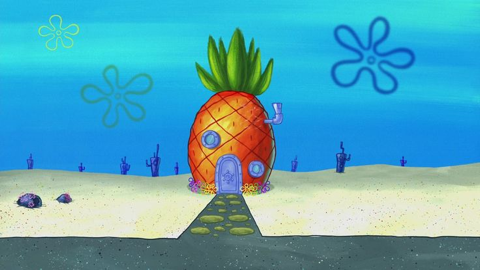
>
> SpongeBob lovingly keeps a precious diary with photos of all his friends. But when he got home after a long day of work at the Krusty Krab, he found a letter from Squidward on top of the diary:
>
> *"Since you annoy me so much, I decided to annoy you too. I tore out 10 random pages of your diary and put impostors in their place. Now your diary is incomplete, and you'll never know where!"*
>
> In despair, SpongeBob asked for your help. **Train a model that finds the impostor pages automatically.**

## Task description

The diary has **3,000 pages** containing pictures of these characters:
- SpongeBob SquarePants
- Patrick Star
- Squidward Tentacles
- Mr. Krabs
- Plankton
- Gary the Snail

Each page is an image with 3 photos of a single character. Exactly **10** of them are impostors: images that don't belong to the original diary.

There is no labeled training set. You have to figure out, from the images alone, which pages stand out from the rest.

## Input

- `data/book.zip`: contains `book/0001.jpg` to `book/3000.jpg`, that is, 3,000 JPEG images
- `data/book_ans.csv`: the 10 impostor pages of the public book (column `page`)
- `data/book_hidden.zip` and `data/book_hidden_ans.csv`: the hidden book used for grading and its answers, used only in the last cell

Each book is about 1.1 GB and lives in the [repository's releases](https://github.com/NOIC-IA/oboia/releases/tag/oboia-2026-impostor). If they aren't in `data/`, the notebook downloads them automatically.

During grading, the hidden book (with different pages and impostors) was placed at the same path as `book.zip`, so nothing had to change.

## Output

The program must create a `predictions.csv` file with **exactly 10 rows**, one per suspicious page:

```csv
page
0042
1337
...
```

`page` is the page number, the same as the file name (from `0001` to `3000`). Repeated pages don't count twice.

## Scoring

Let $k$ be the number of **distinct impostor pages** that appear in your `predictions.csv`. The score grows **exponentially** with $k$, so each extra impostor is worth more than the previous one:

$$\text{score} = \frac{2^{k} - 1}{2^{10} - 1}$$

<table align="center" style="text-align: center">
  <tr><th>Impostors found (<i>k</i>)</th><th>Score</th></tr>
  <tr><td>0</td><td>0.000</td></tr>
  <tr><td>1</td><td>0.001</td></tr>
  <tr><td>2</td><td>0.003</td></tr>
  <tr><td>3</td><td>0.007</td></tr>
  <tr><td>4</td><td>0.015</td></tr>
  <tr><td>5</td><td>0.030</td></tr>
  <tr><td>6</td><td>0.062</td></tr>
  <tr><td>7</td><td>0.124</td></tr>
  <tr><td>8</td><td>0.249</td></tr>
  <tr><td>9</td><td>0.499</td></tr>
  <tr><td><b>10</b></td><td><b>1.000</b></td></tr>
</table>

Each extra impostor roughly **doubles** your score. Finding the 10th is worth as much as the other nine combined.

- Only the **first 10 rows** of the file count. Extra rows are ignored.
- A repeated page counts **only once**.
- `0042` and `42` are the same page.
- If the file has no `page` column, or has a page outside the range `1` to `3000`, the submission is **invalid**.

On the hidden leaderboard, the baseline scored `0.00`, and the best score achieved by the NOIC team was `1.00`.

## Submission

Submit a ZIP file with **exactly one** notebook (`.ipynb`) at the root. The notebook is run from start to finish, on a GPU machine, over the hidden 3,000-page book. When it finishes, it must have created `predictions.csv`:

```csv
page
0042
1337
...
```

- The file has **10 rows** with the suspicious pages, plus the `page` header.
- Page numbers follow the file names, from `0001` to `3000`.
- **Don't** submit a precomputed list of pages: grading runs your code.
- **Don't** include the book, or very large model weights, in the ZIP.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from transformers import CLIPModel, CLIPProcessor

### Loading the data
There are a lot of images, so they come in a single ZIP, `data/book.zip`. If it isn't there yet (on Colab or Kaggle, for example), we first download the public book and its answers (`data/book_ans.csv`). On Kaggle, turn on the **Internet** option in the notebook settings so the download works.

During grading, the hidden book was already at `data/book.zip` and there was no answer file, so nothing was downloaded.

In [2]:
import shutil
import urllib.request

DATA = "data"
BOOK_ZIP = f"{DATA}/book.zip"
ANSWERS = f"{DATA}/book_ans.csv"

BOOK_URL = "https://github.com/NOIC-IA/oboia/releases/download/oboia-2026-impostor/book.zip"
ANSWERS_URL = "https://github.com/NOIC-IA/oboia/releases/download/oboia-2026-impostor/book_ans.csv"


def download(url, destination):
    # Some servers reject Python's default User-Agent (error 403), so we identify ourselves.
    request = urllib.request.Request(url, headers={"User-Agent": "oboia-notebook/1.0"})
    with urllib.request.urlopen(request) as response, open(destination + ".part", "wb") as file:
        shutil.copyfileobj(response, file, length=1024 * 1024)
    os.replace(destination + ".part", destination)  # only rename once the download has finished


# During grading the hidden book is already at data/book.zip: we only download when the file is missing.
if not os.path.exists(BOOK_ZIP):
    os.makedirs(DATA, exist_ok=True)
    print("Downloading book.zip (about 1.1 GB)...")
    download(BOOK_URL, BOOK_ZIP)
    if not os.path.exists(ANSWERS):
        download(ANSWERS_URL, ANSWERS)

Now we unzip the book once into `data/book/` (if the folder already exists, we skip it). We use Python's `zipfile`, which works on any system without needing the `unzip` command.

In [3]:
import zipfile

IMAGES_PATH = f"{DATA}/book"

if not os.path.isdir(IMAGES_PATH):
    with zipfile.ZipFile(BOOK_ZIP) as book:
        book.extractall(DATA)

### Loading CLIP
CLIP is a model that puts text and images in the same latent space. In the baseline we only use the image side.

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device).eval()

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 66332.87it/s]

We'll also store the folder path and the path of each image, to use later. They are named by index, from 0001.jpg to 3000.jpg.

In [5]:
ALL_IMAGES_PATH = [f"{IMAGES_PATH}/{i:04d}.jpg" for i in range(1, len(os.listdir(IMAGES_PATH)) + 1)]

### Generating the embeddings
Now we pass every page through CLIP, in batches, and keep one embedding per page.

In [6]:
BATCH_SIZE = 128
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if DEVICE == "cuda" else torch.float32

feature_batches = []

for start in range(0, len(ALL_IMAGES_PATH), BATCH_SIZE):
    images = []

    # Open the images in RGB
    for index, path in enumerate(ALL_IMAGES_PATH[start:start + BATCH_SIZE], start):
        with Image.open(path) as image:
            images.append(image.convert('RGB'))

    # Apply CLIP's preprocessing so the images can go into the model
    pixels = processor(
        images=images,
        return_tensors='pt'
    )['pixel_values'].to(DEVICE, dtype=dtype)

    # Extract the embeddings with CLIP and normalize each one
    with torch.inference_mode():
        outputs = model.get_image_features(pixel_values=pixels)
        image_features = outputs.pooler_output
        image_features = image_features / image_features.norm(dim=1, keepdim=True)

    feature_batches.append(image_features.float().cpu().numpy())

    # Show progress every 5 batches
    if start and start % (BATCH_SIZE * 5) == 0:
        print(f'{start}/{len(ALL_IMAGES_PATH)} images embedded')

image_embeddings = np.concatenate(feature_batches)

image_embeddings.shape

640/3000 images embedded


1280/3000 images embedded


1920/3000 images embedded


2560/3000 images embedded


(3000, 512)

### Visualizing
There are 512 dimensions, so we reduce them to 2D with t-SNE and UMAP to get an idea of how the pages cluster.

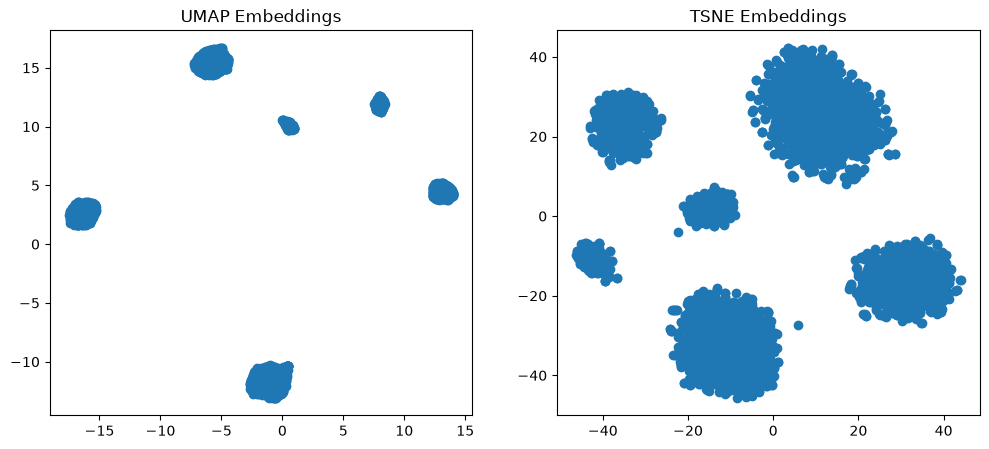

In [7]:
from umap import UMAP
from sklearn.manifold import TSNE

tsne = TSNE(random_state=42)
umap = UMAP(n_jobs=1, random_state=42)

# Reduce the embeddings to 2D so we can visualize them
tsne_embeddings = tsne.fit_transform(image_embeddings)
umap_embeddings = umap.fit_transform(image_embeddings)

# Both side by side, to compare how each one separates the pages
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(umap_embeddings[:, 0], umap_embeddings[:, 1])
plt.title('UMAP Embeddings')

plt.subplot(1, 2, 2)
plt.scatter(tsne_embeddings[:, 0], tsne_embeddings[:, 1])
plt.title('TSNE Embeddings')

plt.show()


### Looking for the isolated ones
The bet is that the impostors are far from everyone else. For each page, we measure the distance to its nearest neighbor in the t-SNE and take the farthest ones.

In [8]:
from sklearn.neighbors import NearestNeighbors

# Distance from each point to its 2 nearest neighbors in the t-SNE
nn = NearestNeighbors(n_neighbors=2)
nn.fit(tsne_embeddings)
distances, indices = nn.kneighbors(tsne_embeddings)

# Each point's nearest neighbor is itself, so we look at the second one.
# The 10 most isolated images in the t-SNE are our impostor candidates.
outliers = np.argsort(-distances[:, 1], kind="stable")[:10]

Let's plot them and check by eye.

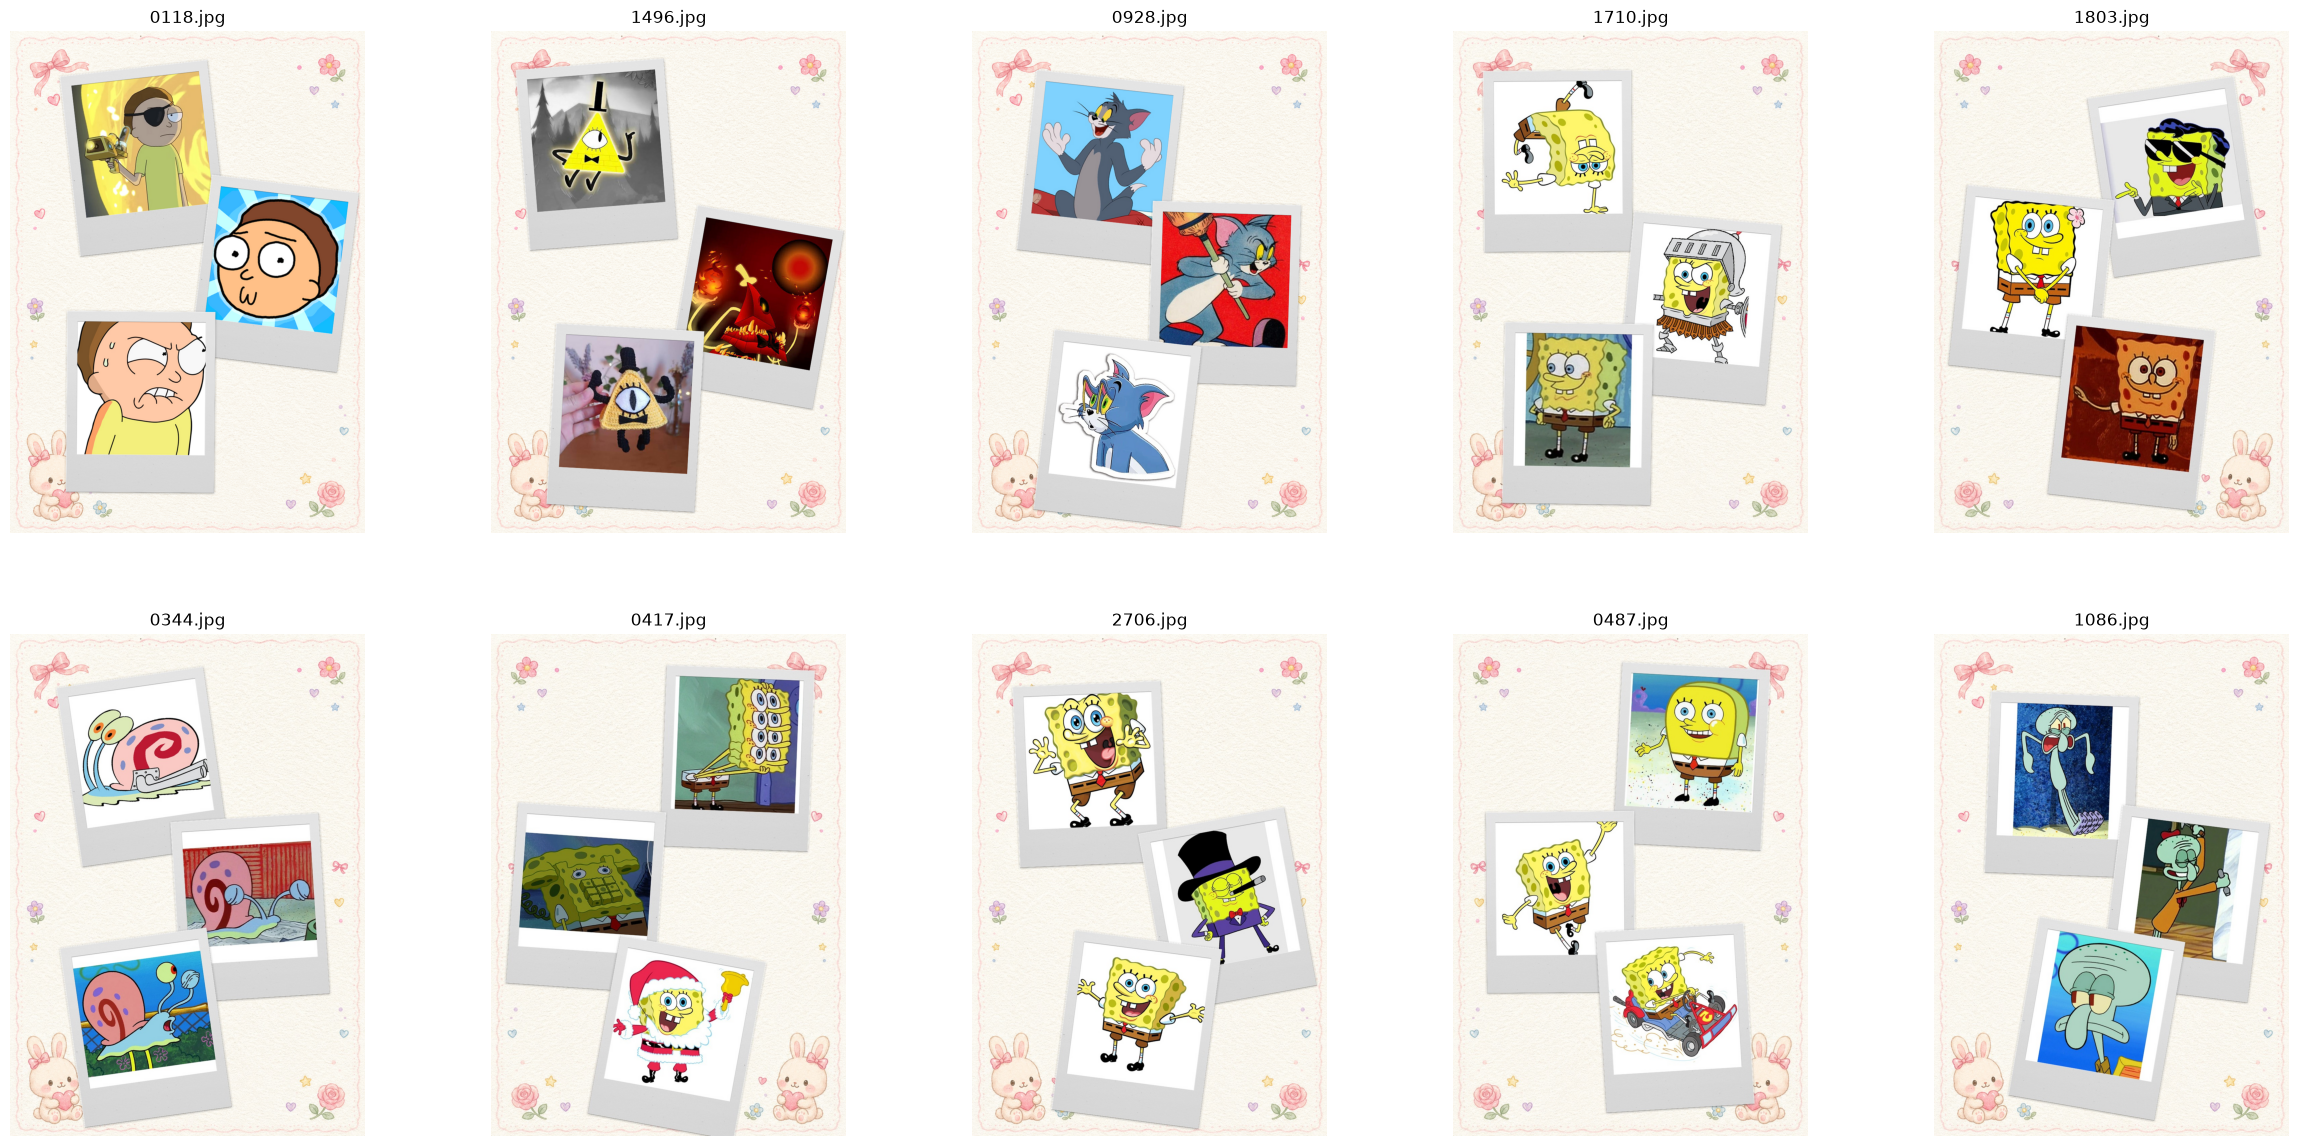

In [9]:
plt.figure(figsize=(30, 30))

for i, idx in enumerate(outliers):
    img = plt.imread(ALL_IMAGES_PATH[int(idx)])
    plt.subplot(4, 5, i + 1)
    plt.imshow(img)
    plt.title(os.path.basename(ALL_IMAGES_PATH[int(idx)]))
    plt.axis("off")

plt.show()

### Saving the predictions
Finally, we save the 10 candidates to `predictions.csv`, one per row, in the `page` column. The page number is the same as the file name (from `0001` to `3000`).

In [10]:
# Indices start at 0, so the page number is index + 1
pages = [f"{int(idx) + 1:04d}" for idx in outliers]

predictions = pd.DataFrame({"page": pages})
predictions.to_csv("predictions.csv", index=False)

predictions

,page
0,0118
1,1496
2,0928
3,1710
4,1803
5,0344
6,0417
7,2706
8,0487
9,1086


### Local evaluation
When `data/book_ans.csv` is available, we compute the score the same way grading does: $k$ is the number of distinct impostor pages among the first 10 rows of `predictions.csv`, and

$$\text{score} = \frac{2^{k} - 1}{2^{10} - 1}$$

During private grading this file doesn't exist, so the cell simply moves on without raising an exception.

In [11]:
if os.path.exists(ANSWERS):
    impostors = set(pd.read_csv(ANSWERS, dtype=str)["page"].astype(int))
    predicted = set(pd.read_csv("predictions.csv", dtype=str)["page"].head(10).astype(int))  # "0042" and "42" are the same page

    k = len(predicted & impostors)
    score = (2**k - 1) / (2**10 - 1)

    print(f"Impostors found: {k} of 10")
    print(f"Score on the public book: {score:.3f}")

Impostors found: 3 of 10
Score on the public book: 0.007


### Bonus: score on the hidden book
This wasn't part of the contest: we run the same method on the hidden book used for grading (`data/book_hidden.zip`) and compare it with its answers (`data/book_hidden_ans.csv`). If the files aren't in `data/`, the cell downloads them from the repository's releases.

In [12]:
HIDDEN_ZIP = f"{DATA}/book_hidden.zip"
HIDDEN_ANSWERS = f"{DATA}/book_hidden_ans.csv"
HIDDEN_DIR = f"{DATA}/hidden"

if not os.path.exists(HIDDEN_ZIP):
    print("Downloading book_hidden.zip (about 1.1 GB)...")
    download("https://github.com/NOIC-IA/oboia/releases/download/oboia-2026-impostor/book_hidden.zip", HIDDEN_ZIP)
if not os.path.exists(HIDDEN_ANSWERS):
    download("https://github.com/NOIC-IA/oboia/releases/download/oboia-2026-impostor/book_hidden_ans.csv", HIDDEN_ANSWERS)
if not os.path.isdir(f"{HIDDEN_DIR}/book"):
    with zipfile.ZipFile(HIDDEN_ZIP) as book:
        book.extractall(HIDDEN_DIR)

hidden_pages = [f"{HIDDEN_DIR}/book/{i:04d}.jpg" for i in range(1, len(os.listdir(f"{HIDDEN_DIR}/book")) + 1)]

# Same pipeline as the baseline: CLIP embeddings, t-SNE and the 10 most isolated pages.
batches = []
for start in range(0, len(hidden_pages), BATCH_SIZE):
    images = []
    for path in hidden_pages[start:start + BATCH_SIZE]:
        with Image.open(path) as image:
            images.append(image.convert("RGB"))
    pixels = processor(images=images, return_tensors="pt")["pixel_values"].to(DEVICE, dtype=dtype)
    with torch.inference_mode():
        features = model.get_image_features(pixel_values=pixels).pooler_output
        features = features / features.norm(dim=1, keepdim=True)
    batches.append(features.float().cpu().numpy())
hidden_embeddings = np.concatenate(batches)

hidden_tsne = TSNE(random_state=42).fit_transform(hidden_embeddings)
distances, _ = NearestNeighbors(n_neighbors=2).fit(hidden_tsne).kneighbors(hidden_tsne)
hidden_predicted = {int(i) + 1 for i in np.argsort(-distances[:, 1], kind="stable")[:10]}

hidden_impostors = set(pd.read_csv(HIDDEN_ANSWERS, dtype=str)["page"].astype(int))
hidden_k = len(hidden_predicted & hidden_impostors)

print(f"Impostors found in the hidden book: {hidden_k} of 10")
print(f"Score on the hidden book: {(2**hidden_k - 1) / (2**10 - 1):.3f}")

Impostors found in the hidden book: 2 of 10
Score on the hidden book: 0.003


Let's look at the 10 pages picked in the hidden book, marking which ones are real impostors.

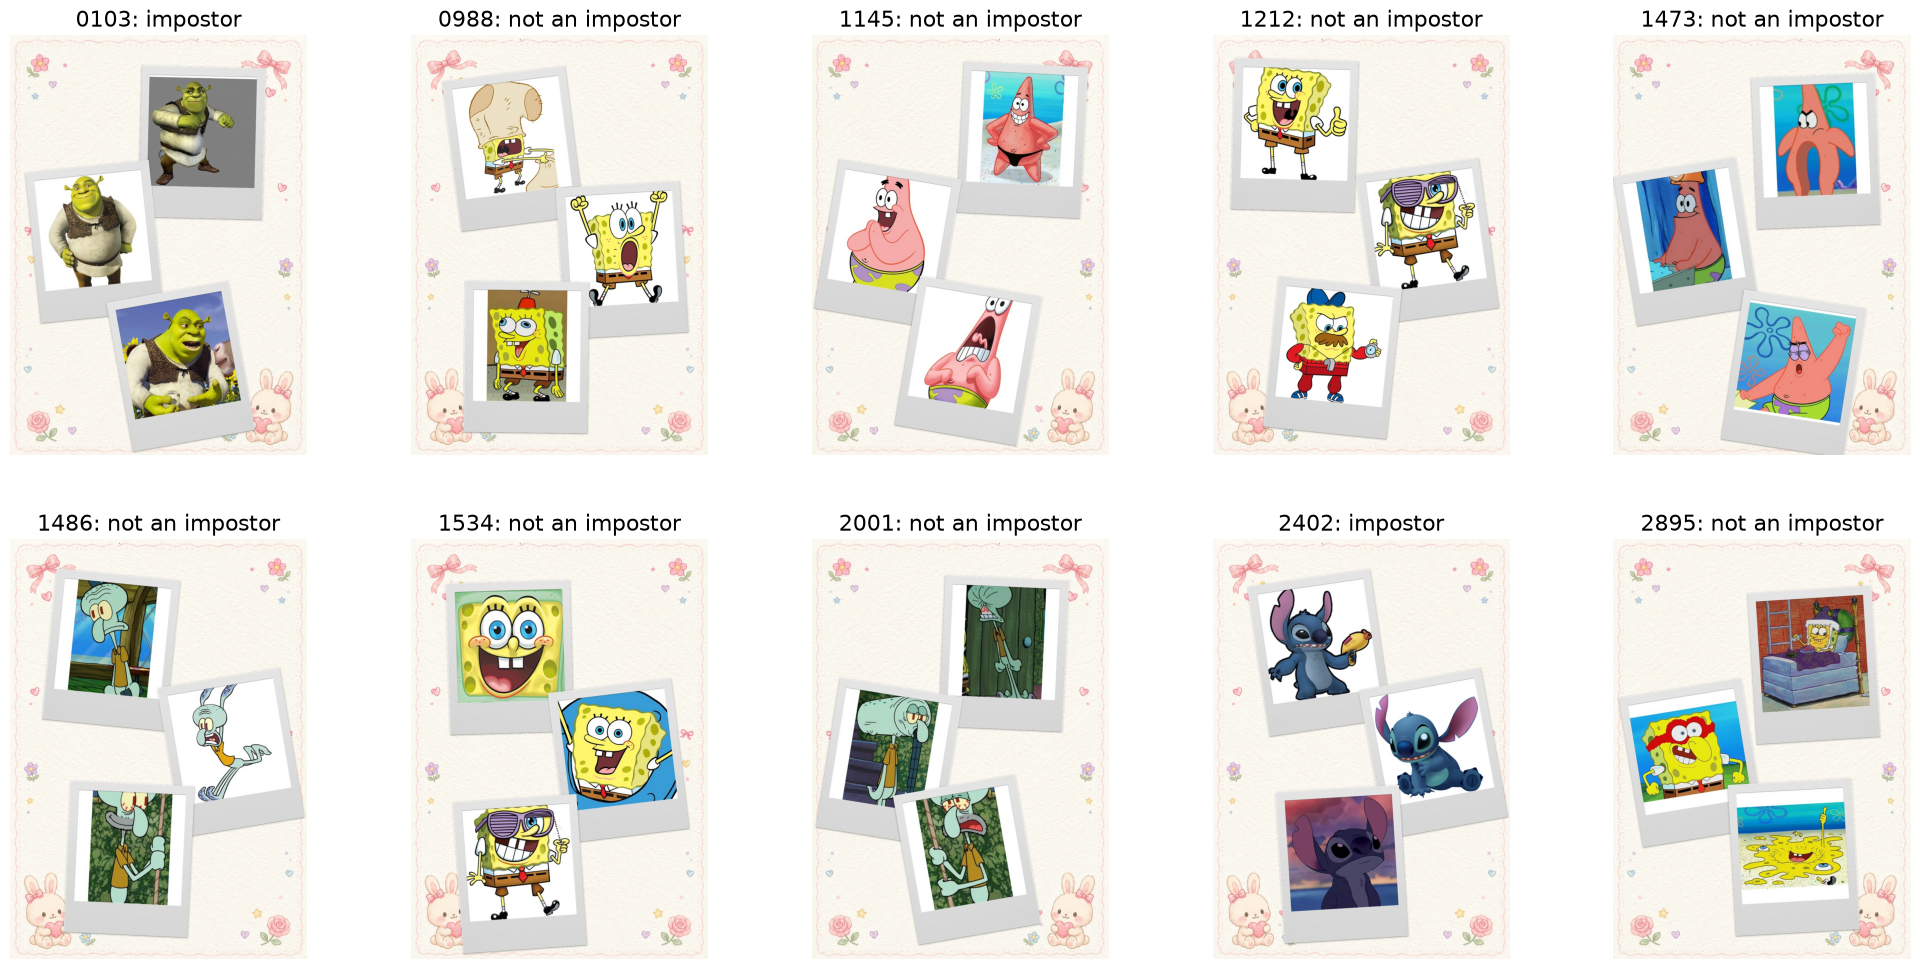

In [13]:
plt.figure(figsize=(25, 12))

for i, page in enumerate(sorted(hidden_predicted)):
    plt.subplot(2, 5, i + 1)
    plt.imshow(plt.imread(f"{HIDDEN_DIR}/book/{page:04d}.jpg"))
    plt.title(f"{page:04d}: " + ("impostor" if page in hidden_impostors else "not an impostor"), fontsize=16)
    plt.axis("off")

plt.show()